In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv('insurance.csv')

# EDA

In [50]:
df.shape

(1338, 7)

In [51]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [53]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [54]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [55]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [56]:
numericals_cols = ['age', 'bmi', 'children', 'charges']

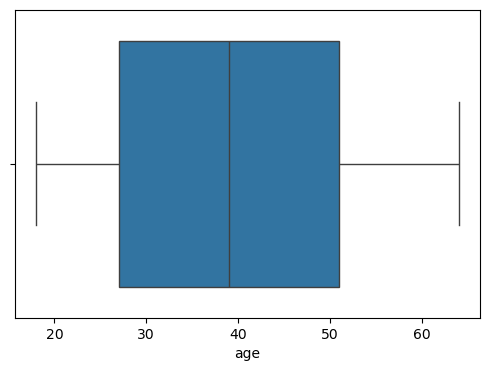

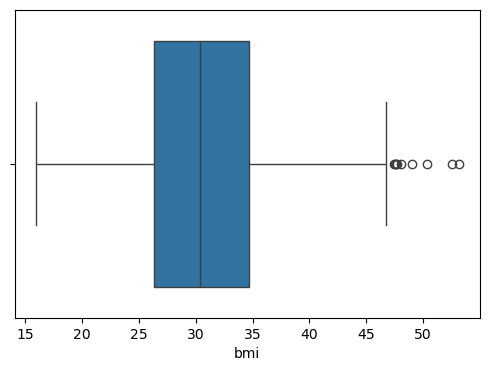

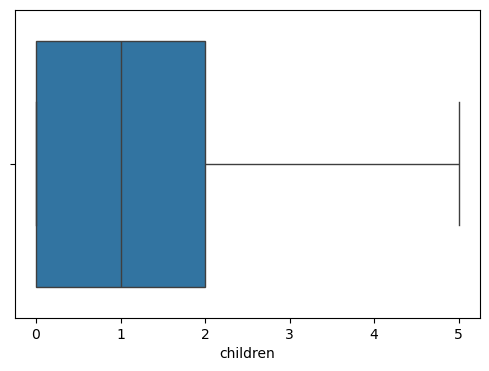

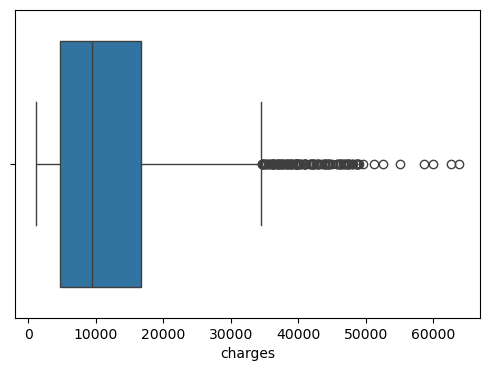

In [57]:
for col in numericals_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x = df[col])

<Axes: xlabel='children', ylabel='count'>

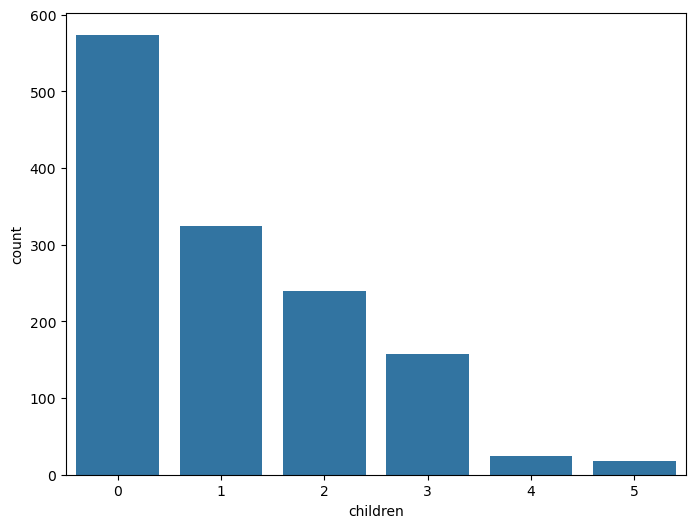

In [58]:
plt.figure(figsize=(8, 6))
sns.countplot(x = df['children'])

<Axes: xlabel='smoker', ylabel='count'>

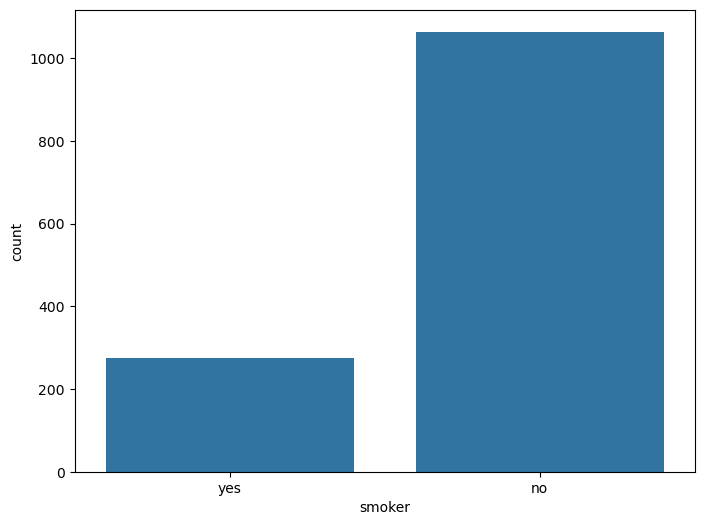

In [59]:
plt.figure(figsize=(8, 6))
sns.countplot(x = df['smoker'])

<Axes: xlabel='sex', ylabel='count'>

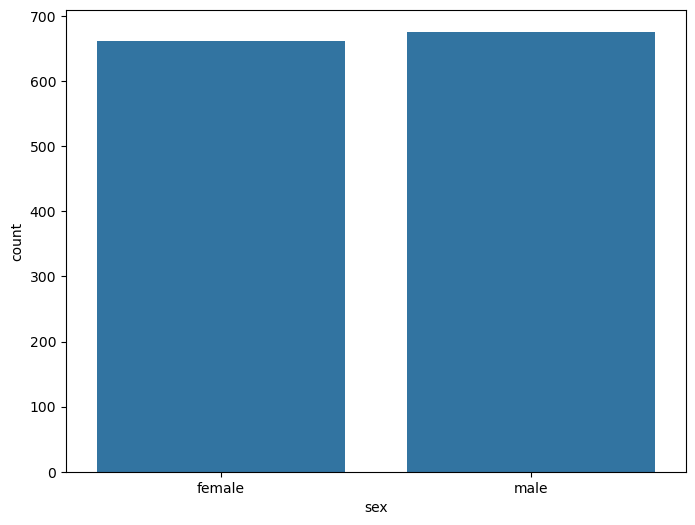

In [60]:
plt.figure(figsize=(8, 6))
sns.countplot(x = df['sex'])

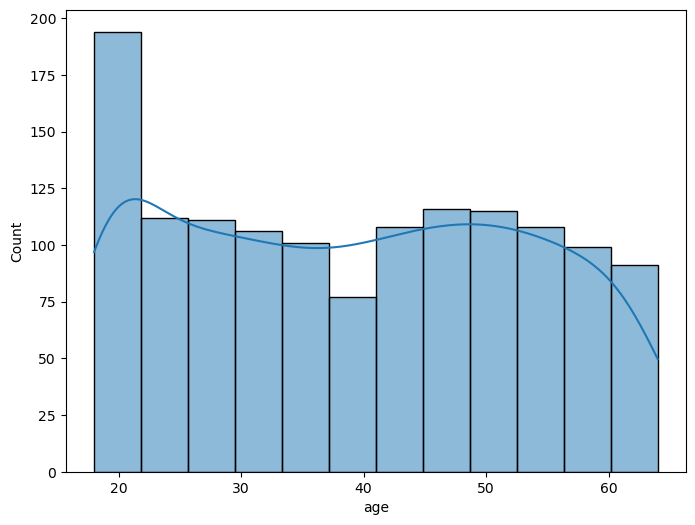

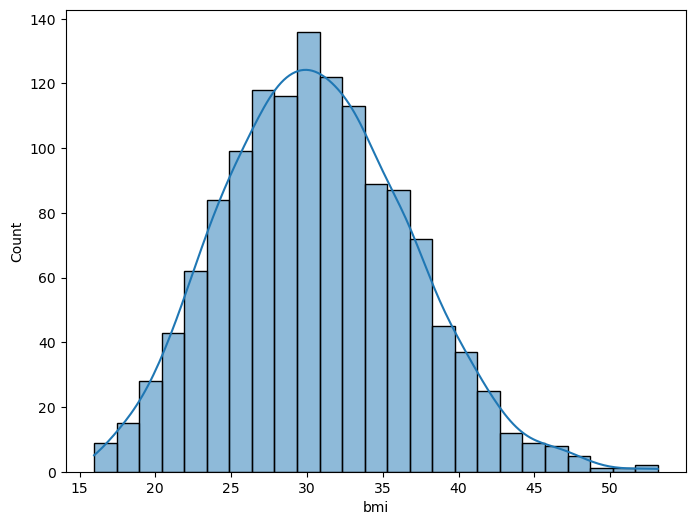

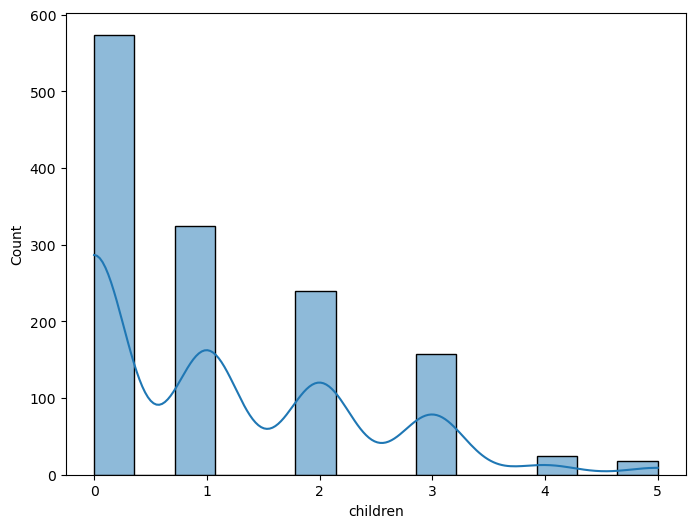

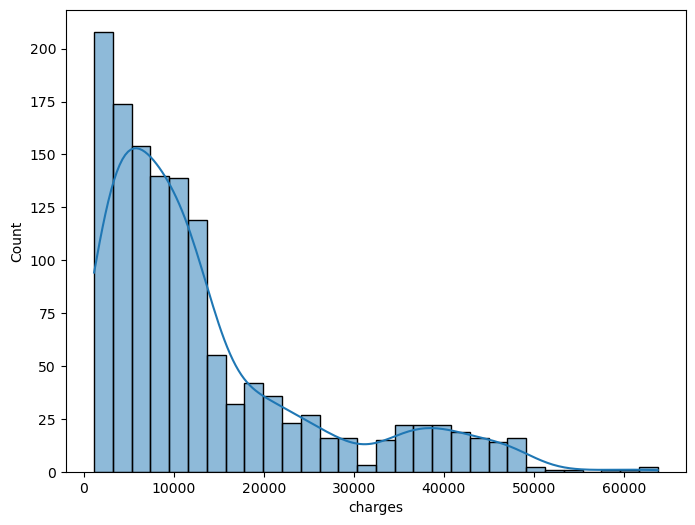

In [61]:
for col in numericals_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)

<Axes: >

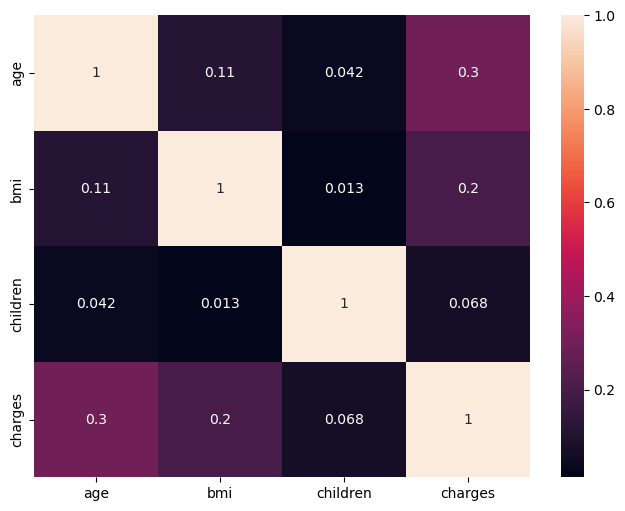

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Cleaning and Preprocessing

In [63]:
df_cleaned = df.copy()

In [64]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [65]:
df_cleaned.shape

(1338, 7)

In [66]:
df_cleaned.drop_duplicates(inplace=True)

In [67]:
df_cleaned.shape

(1337, 7)

In [68]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [69]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [70]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [71]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male' : 0, 'female' : 1})

In [72]:
df_cleaned['smoker'].value_counts() 

smoker
no     1063
yes     274
Name: count, dtype: int64

In [73]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no' : 0, 'yes' : 1})

In [74]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [75]:
df_cleaned.rename(columns={
    'sex' : 'is_female', 
    'smoker' : 'is_smoker'
}, inplace=True)

In [76]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [77]:
df_cleaned['is_female'].astype(int)
df_cleaned['is_smoker'].astype(int)

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: is_smoker, Length: 1337, dtype: int64

In [78]:
df_cleaned.dtypes

age            int64
is_female      int64
bmi          float64
children       int64
is_smoker      int64
region        object
charges      float64
dtype: object

In [79]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [80]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [81]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [82]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   is_female         1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   is_smoker         1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 77.0 KB


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

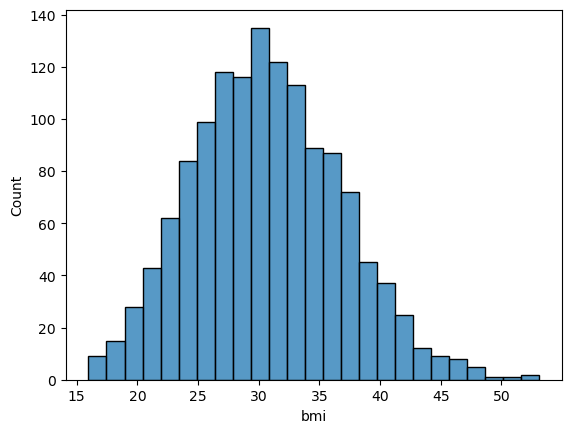

In [83]:
sns.histplot(df_cleaned['bmi'])

In [84]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], 
                                    bins=[0, 18.5, 24.9, 29.9, float('inf')], 
                                    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
                                   )

In [85]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [90]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False


In [92]:
df_cleaned = df_cleaned.astype(int)

In [93]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [94]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [95]:
from sklearn.preprocessing import StandardScaler

In [96]:
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [97]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


### Feature Extraction

In [111]:
from scipy.stats import pearsonr

selected_features = [
    'age',
    'children',
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]
results = []
for feature in selected_features:
    r, p = pearsonr(df_cleaned[feature], df_cleaned['charges'])
    
    results.append({
        'Feature': feature,
        'Correlation': r,
        'p_value' : p
    })

corr_df = pd.DataFrame(results)

print(corr_df.sort_values(by='Correlation', ascending=False))

                   Feature  Correlation        p_value
3                is_smoker     0.787234  1.409109e-282
0                      age     0.298309   6.974243e-29
9       bmi_category_Obese     0.197660   3.036759e-13
5         region_southeast     0.073577   7.113509e-03
1                 children     0.067390   1.371578e-02
4         region_northwest    -0.038695   1.573341e-01
6         region_southwest    -0.043637   1.107449e-01
2                is_female    -0.058046   3.381675e-02
7      bmi_category_Normal    -0.105656   1.086031e-04
8  bmi_category_Overweight    -0.118280   1.450377e-05


Feature Selection Criteria based on Pearson Correlation:

- Correlation > 0.50: The feature is highly correlated with the target variable (charges) and is considered strongly related.
- Correlation between 0.20 and 0.50: The feature is moderately correlated with the target and is considered meaningfully related.
- Correlation between 0.10 and 0.20: The feature has a weak correlation with the target and is considered negotiable for feature selection.
- Correlation < 0.10: The feature has a very weak or negligible relationship with the target and can generally be considered for removal.

In [109]:
cat_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]

In [112]:
from scipy.stats import chi2_contingency
alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q = 4, labels = False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stats, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistics' : chi2_stats,
        'p_value' : p_val,
        'Decision' : decision
    }

In [117]:
chi2_Results = pd.DataFrame(chi2_results).T

In [118]:
chi2_Results = chi2_Results.sort_values(by = 'p_value')
chi2_Results

,chi2_statistics,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [121]:
final_df = df_cleaned[['age', 'bmi', 'is_female', 'children', 'is_smoker', 'charges', 'region_southeast', 'bmi_category_Obese']]

In [122]:
final_df.head()

,age,bmi,is_female,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,-0.517949,1,-0.909234,1,16884,0,0
1,-1.511647,0.462463,0,-0.079442,0,1725,1,1
2,-0.799350,0.462463,0,1.580143,0,4449,1,1
3,-0.443201,-1.334960,0,-0.909234,0,21984,0,0
4,-0.514431,-0.354547,0,-0.909234,0,3866,0,0
